In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("All libraries loaded ✅")

All libraries loaded ✅


In [9]:
# 21 sensors + operational settings + id/cycle columns
col_names = [
    'engine_id', 'cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
    'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
    'sensor_21'
]

print(f"Total columns defined: {len(col_names)}")

Total columns defined: 26


In [10]:
def load_cmapss(subset, split='train'):
    path = f'../data/raw/{split}_FD00{subset}.txt'
    df = pd.read_csv(path, sep='\s+', header=None, names=col_names)
    df['subset'] = f'FD00{subset}'
    df['split'] = split
    return df

# Load all train sets
train_dfs = [load_cmapss(i, 'train') for i in range(1, 5)]
train_df = pd.concat(train_dfs, ignore_index=True)

# Load all test sets
test_dfs = [load_cmapss(i, 'test') for i in range(1, 5)]
test_df = pd.concat(test_dfs, ignore_index=True)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
train_df.head()

Train shape: (160359, 28)
Test shape:  (104897, 28)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,subset,split
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001,train
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001,train
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001,train
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001,train
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001,train


In [11]:
# RUL = how many cycles left before engine fails
# For training data we calculate it from max cycle per engine

def add_rul(df):
    max_cycle = df.groupby(['engine_id', 'subset'])['cycle'].max().reset_index()
    max_cycle.columns = ['engine_id', 'subset', 'max_cycle']
    df = df.merge(max_cycle, on=['engine_id', 'subset'])
    df['RUL'] = df['max_cycle'] - df['cycle']
    df.drop(columns=['max_cycle'], inplace=True)
    return df

train_df = add_rul(train_df)

print("RUL added ✅")
print(f"RUL range: {train_df['RUL'].min()} to {train_df['RUL'].max()} cycles")
train_df[['engine_id', 'cycle', 'RUL', 'subset']].head(10)

RUL added ✅
RUL range: 0 to 542 cycles


,engine_id,cycle,RUL,subset
0,1,1,191,FD001
1,1,2,190,FD001
2,1,3,189,FD001
3,1,4,188,FD001
4,1,5,187,FD001
5,1,6,186,FD001
6,1,7,185,FD001
7,1,8,184,FD001
8,1,9,183,FD001
9,1,10,182,FD001


In [12]:
print("=== DATASET INFO ===")
print(f"Total engines (train): {train_df['engine_id'].nunique()}")
print(f"Total rows (train):    {len(train_df)}")
print(f"\n=== MISSING VALUES ===")
print(train_df.isnull().sum().sum(), "missing values found")

print(f"\n=== BASIC STATS ===")
train_df.describe().round(2)

=== DATASET INFO ===
Total engines (train): 260
Total rows (train):    160359

=== MISSING VALUES ===
0 missing values found

=== BASIC STATS ===


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
count,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,...,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00
mean,105.55,123.33,17.21,0.41,95.72,485.84,597.36,1467.04,1260.96,9.89,...,2349.65,8088.95,9.05,0.03,360.70,2273.75,98.39,25.94,15.57,122.33
std,72.87,83.54,16.53,0.37,12.36,30.42,42.48,118.18,136.30,4.27,...,111.17,80.62,0.75,0.00,31.02,142.51,4.66,11.69,7.02,83.54
min,1.00,1.00,-0.01,-0.00,60.00,445.00,535.48,1242.67,1023.77,3.91,...,2027.57,7845.78,8.16,0.02,302.00,1915.00,84.93,10.16,6.01,0.00
25%,44.00,57.00,0.00,0.00,100.00,449.44,549.96,1357.36,1126.83,5.48,...,2387.97,8070.53,8.44,0.02,332.00,2212.00,100.00,14.33,8.60,56.00
50%,89.00,114.00,20.00,0.62,100.00,489.05,605.93,1492.81,1271.74,9.35,...,2388.07,8118.59,9.03,0.03,367.00,2319.00,100.00,24.92,14.95,113.00
75%,164.00,173.00,35.00,0.84,100.00,518.67,642.34,1586.59,1402.20,14.62,...,2388.16,8139.41,9.34,0.03,392.00,2388.00,100.00,38.82,23.29,172.00
max,260.00,543.00,42.01,0.84,100.00,518.67,645.11,1616.91,1441.49,14.62,...,2390.49,8293.72,11.07,0.03,400.00,2388.00,100.00,39.89,23.95,542.00


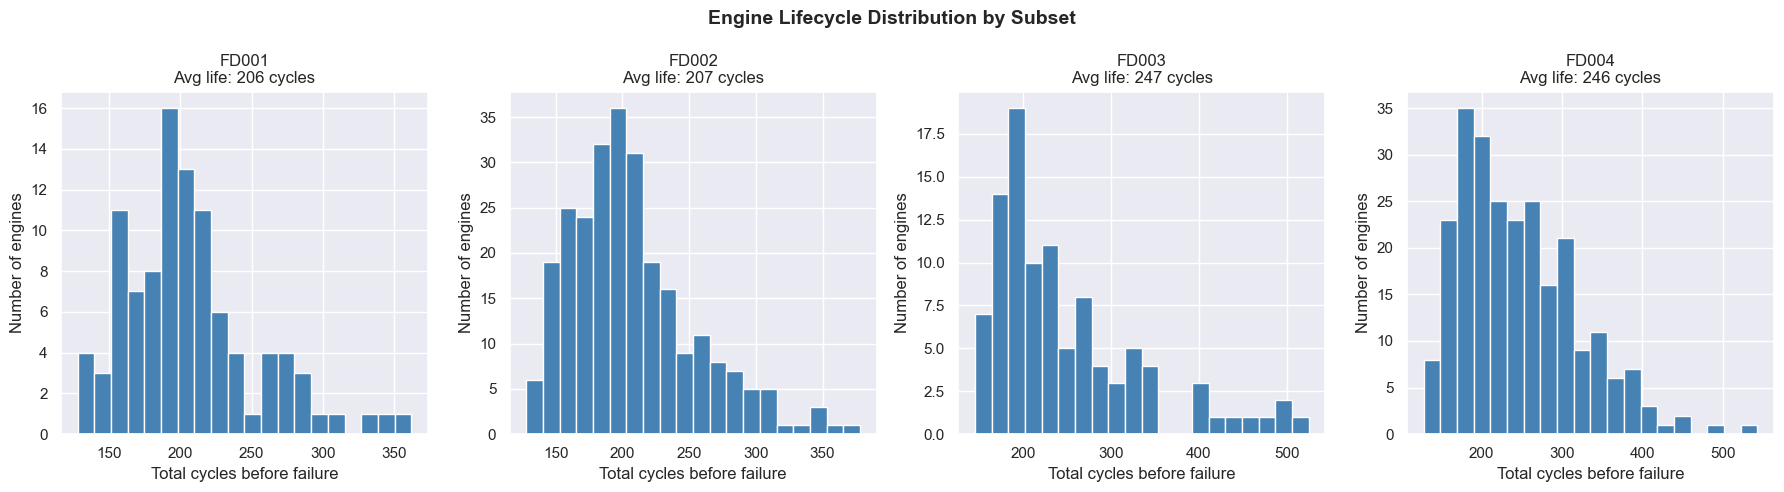

Plot 1 saved ✅


In [13]:
engine_life = train_df.groupby(['subset', 'engine_id'])['cycle'].max().reset_index()
engine_life.columns = ['subset', 'engine_id', 'max_cycles']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, subset in enumerate(['FD001', 'FD002', 'FD003', 'FD004']):
    data = engine_life[engine_life['subset'] == subset]['max_cycles']
    axes[i].hist(data, bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{subset}\nAvg life: {data.mean():.0f} cycles')
    axes[i].set_xlabel('Total cycles before failure')
    axes[i].set_ylabel('Number of engines')

plt.suptitle('Engine Lifecycle Distribution by Subset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot1_engine_lifecycle.png', dpi=150)
plt.show()
print("Plot 1 saved ✅")

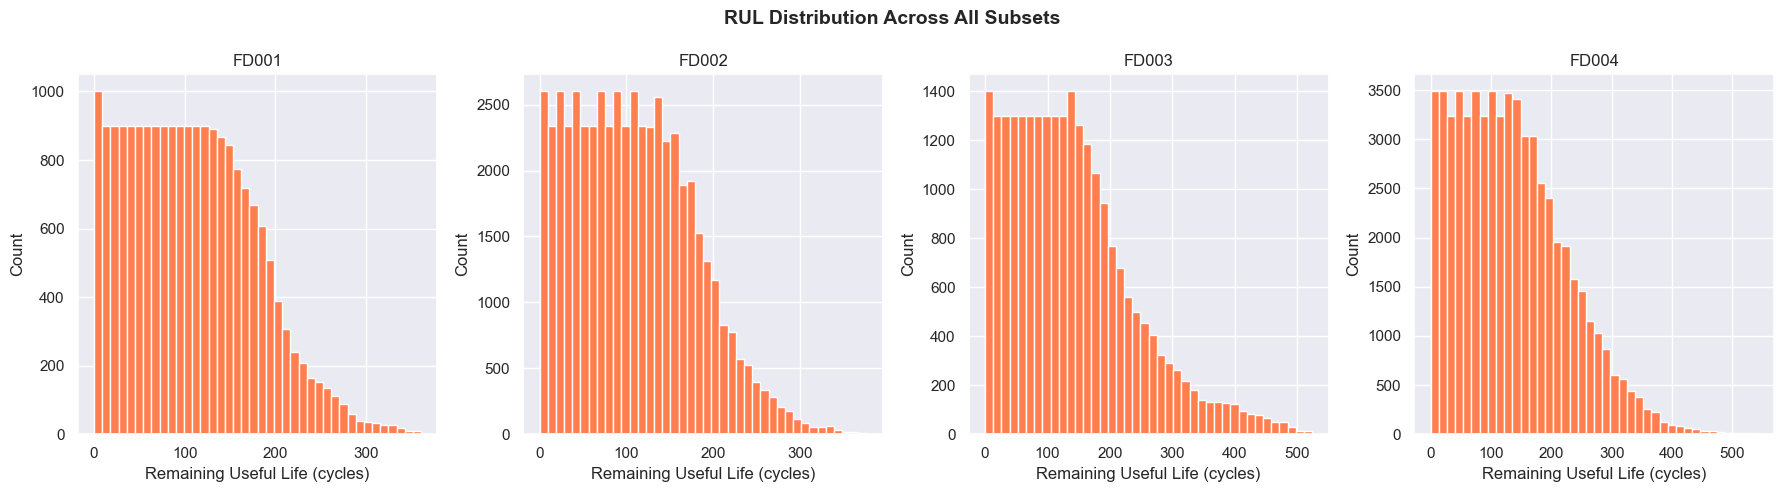

Plot 2 saved ✅


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, subset in enumerate(['FD001', 'FD002', 'FD003', 'FD004']):
    data = train_df[train_df['subset'] == subset]['RUL']
    axes[i].hist(data, bins=40, color='coral', edgecolor='white')
    axes[i].set_title(f'{subset}')
    axes[i].set_xlabel('Remaining Useful Life (cycles)')
    axes[i].set_ylabel('Count')

plt.suptitle('RUL Distribution Across All Subsets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot2_rul_distribution.png', dpi=150)
plt.show()
print("Plot 2 saved ✅")

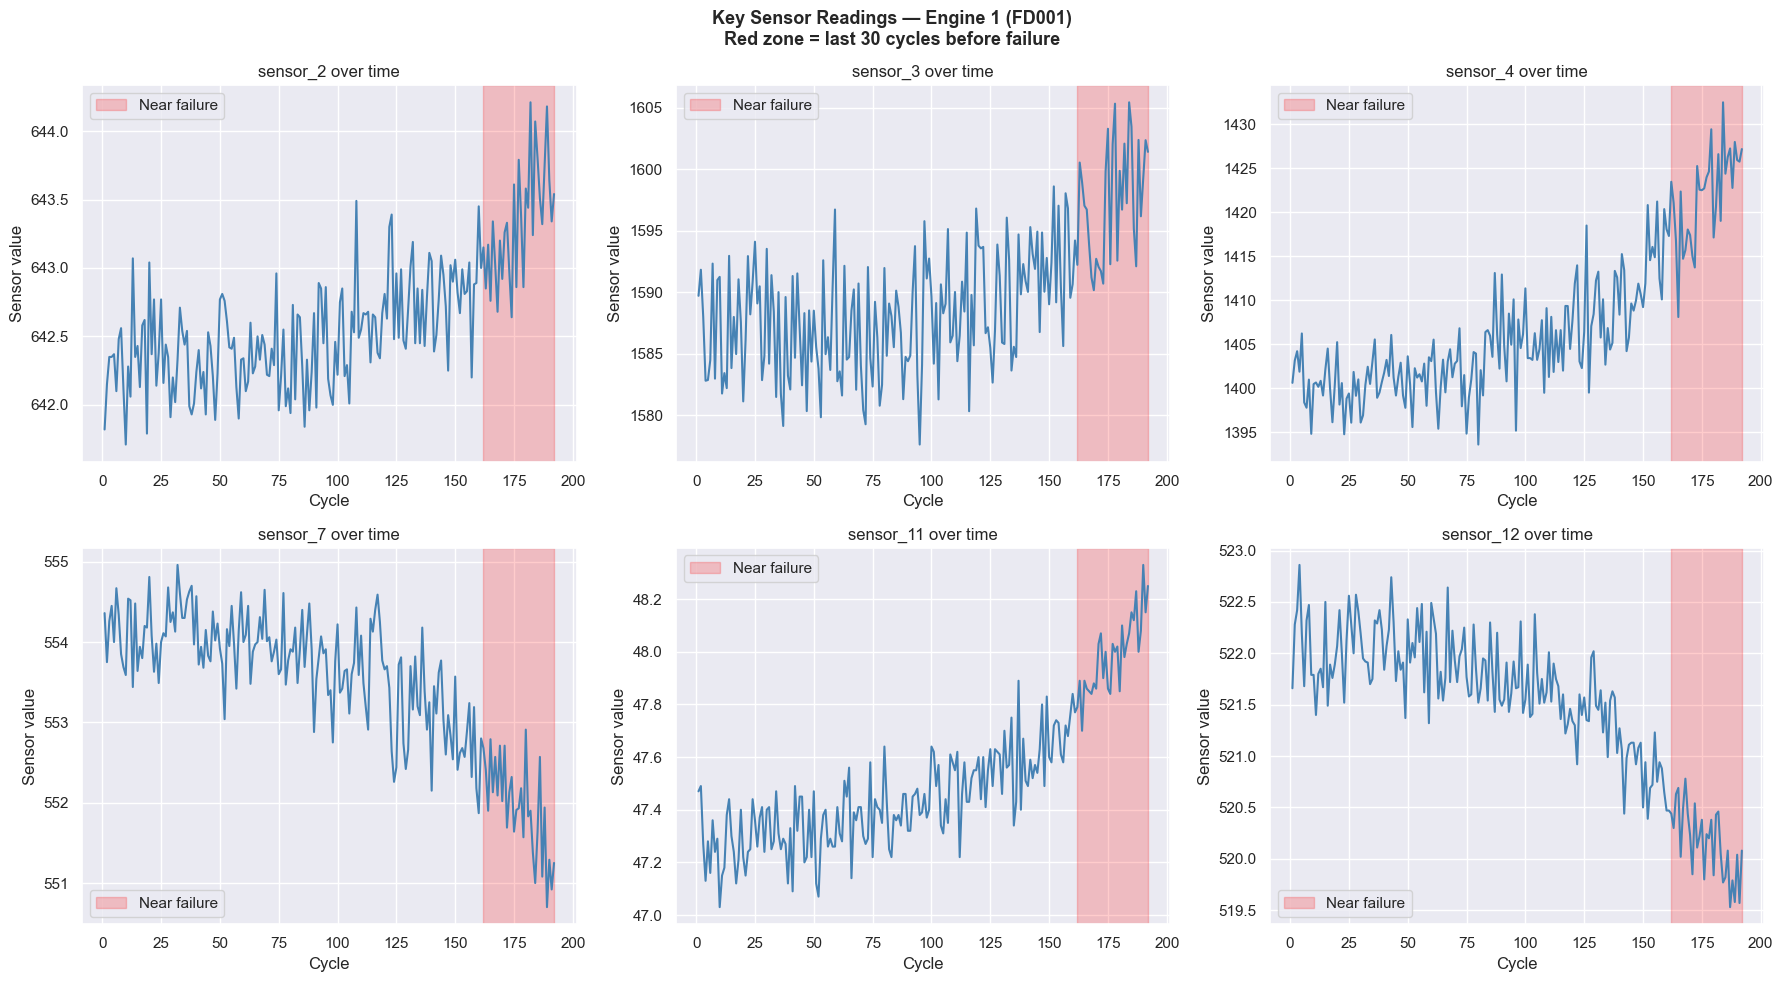

Plot 3 saved ✅


In [15]:
# Pick engine 1 from FD001 to track degradation over its lifetime
engine_sample = train_df[(train_df['engine_id'] == 1) & 
                          (train_df['subset'] == 'FD001')]

# Most informative sensors (known from domain knowledge)
key_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 
               'sensor_7', 'sensor_11', 'sensor_12']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sensor in enumerate(key_sensors):
    axes[i].plot(engine_sample['cycle'], engine_sample[sensor], 
                 color='steelblue', linewidth=1.5)
    axes[i].set_title(f'{sensor} over time')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Sensor value')
    # Mark the last 30 cycles (near failure zone) in red
    near_failure = engine_sample[engine_sample['RUL'] <= 30]
    axes[i].axvspan(near_failure['cycle'].min(), 
                    near_failure['cycle'].max(), 
                    alpha=0.2, color='red', label='Near failure')
    axes[i].legend()

plt.suptitle('Key Sensor Readings — Engine 1 (FD001)\nRed zone = last 30 cycles before failure', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot3_sensor_degradation.png', dpi=150)
plt.show()
print("Plot 3 saved ✅")

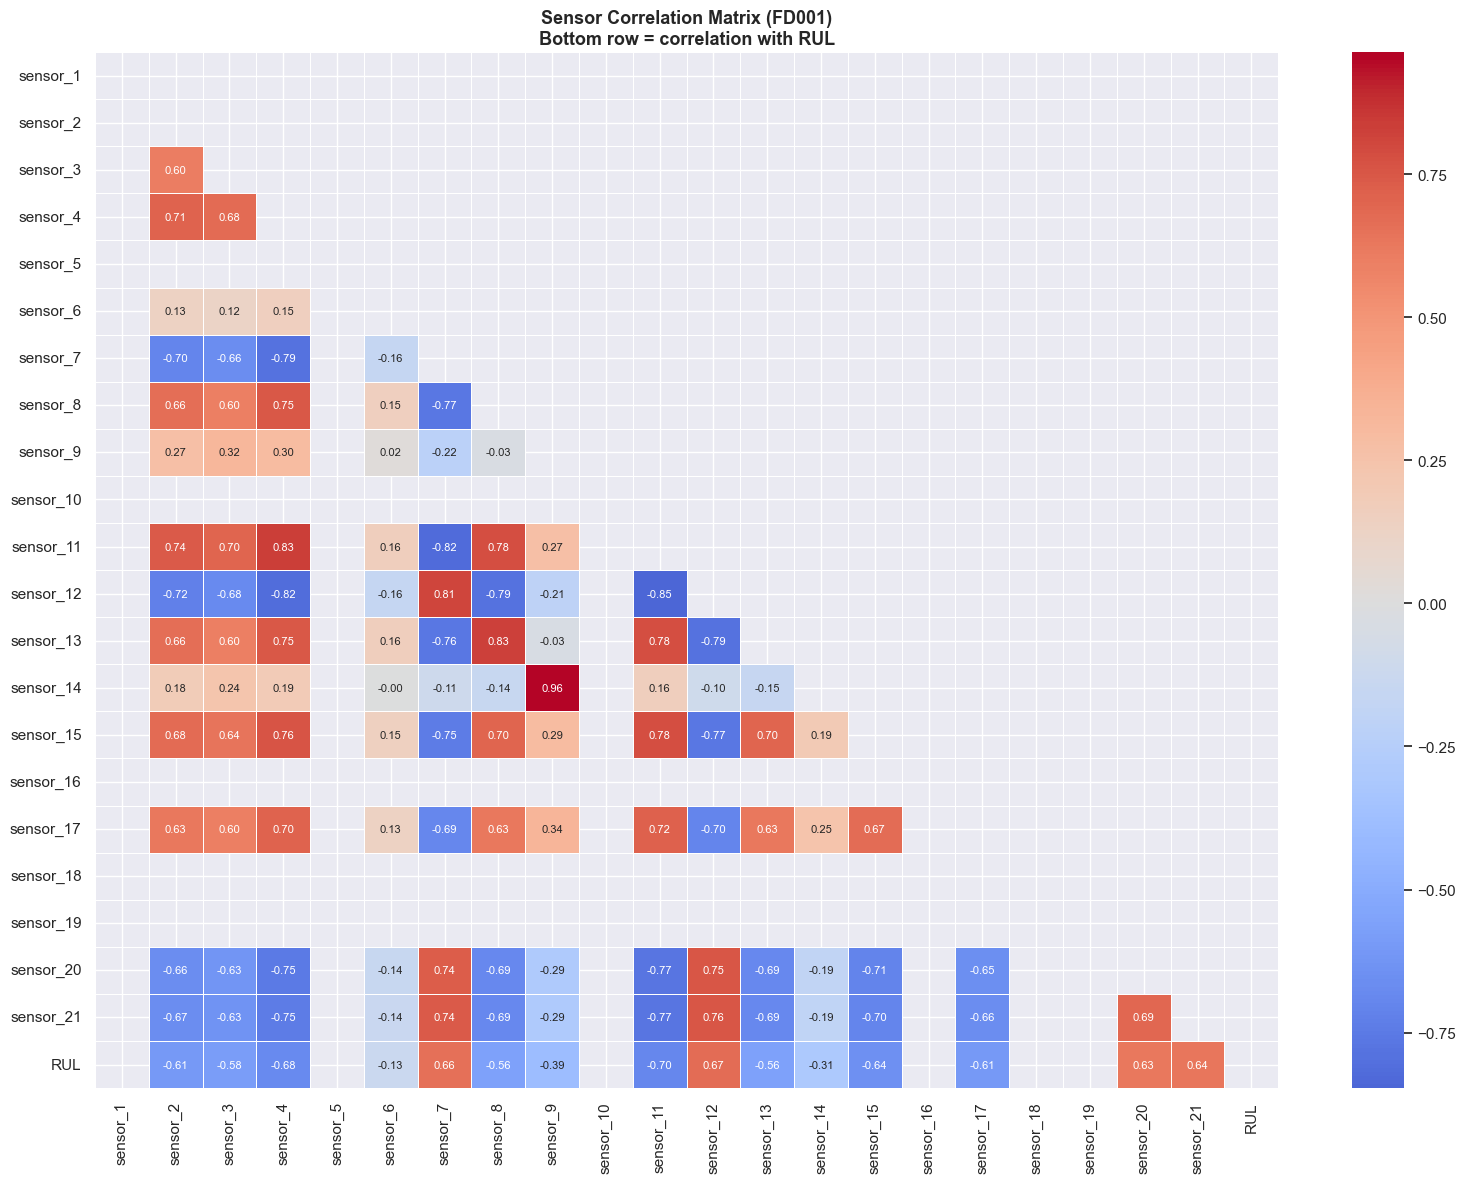

Plot 4 saved ✅


In [16]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
fd001 = train_df[train_df['subset'] == 'FD001']

corr_matrix = fd001[sensor_cols + ['RUL']].corr()

plt.figure(figsize=(16, 12))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Sensor Correlation Matrix (FD001)\nBottom row = correlation with RUL', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot4_correlation_heatmap.png', dpi=150)
plt.show()
print("Plot 4 saved ✅")

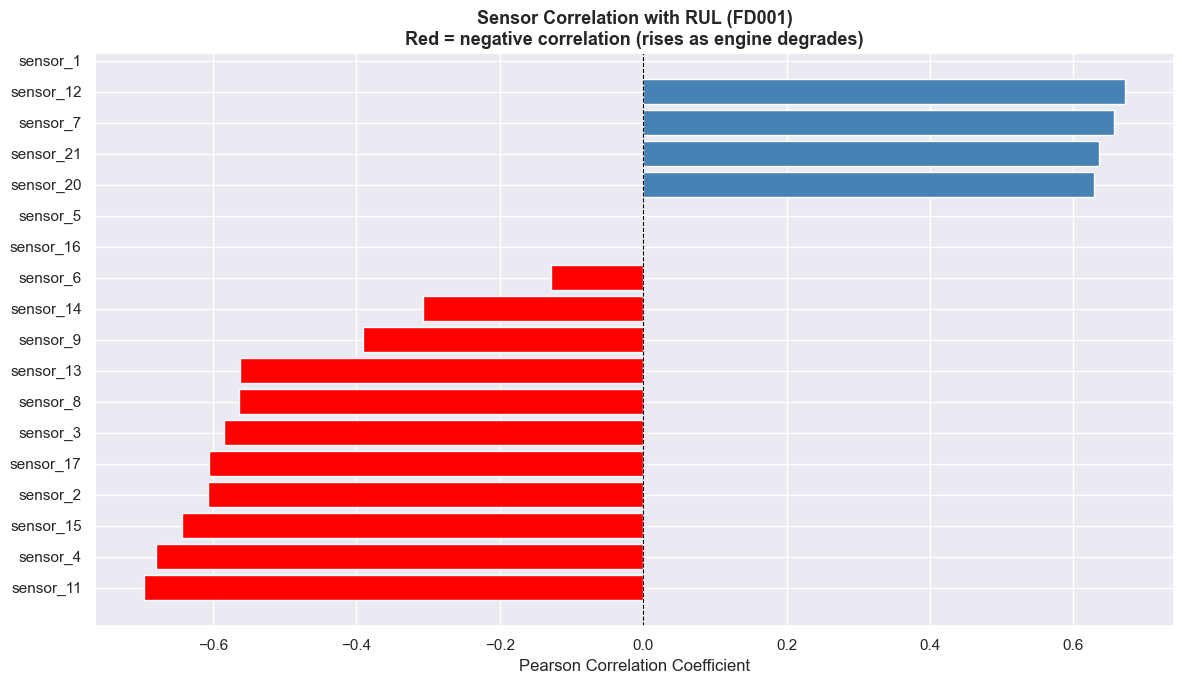

Plot 5 saved ✅


In [17]:
rul_corr = fd001[sensor_cols].corrwith(fd001['RUL']).sort_values()

colors = ['red' if x < 0 else 'steelblue' for x in rul_corr.values]

plt.figure(figsize=(12, 7))
bars = plt.barh(rul_corr.index, rul_corr.values, color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Sensor Correlation with RUL (FD001)\nRed = negative correlation (rises as engine degrades)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../data/processed/plot5_rul_correlation.png', dpi=150)
plt.show()
print("Plot 5 saved ✅")

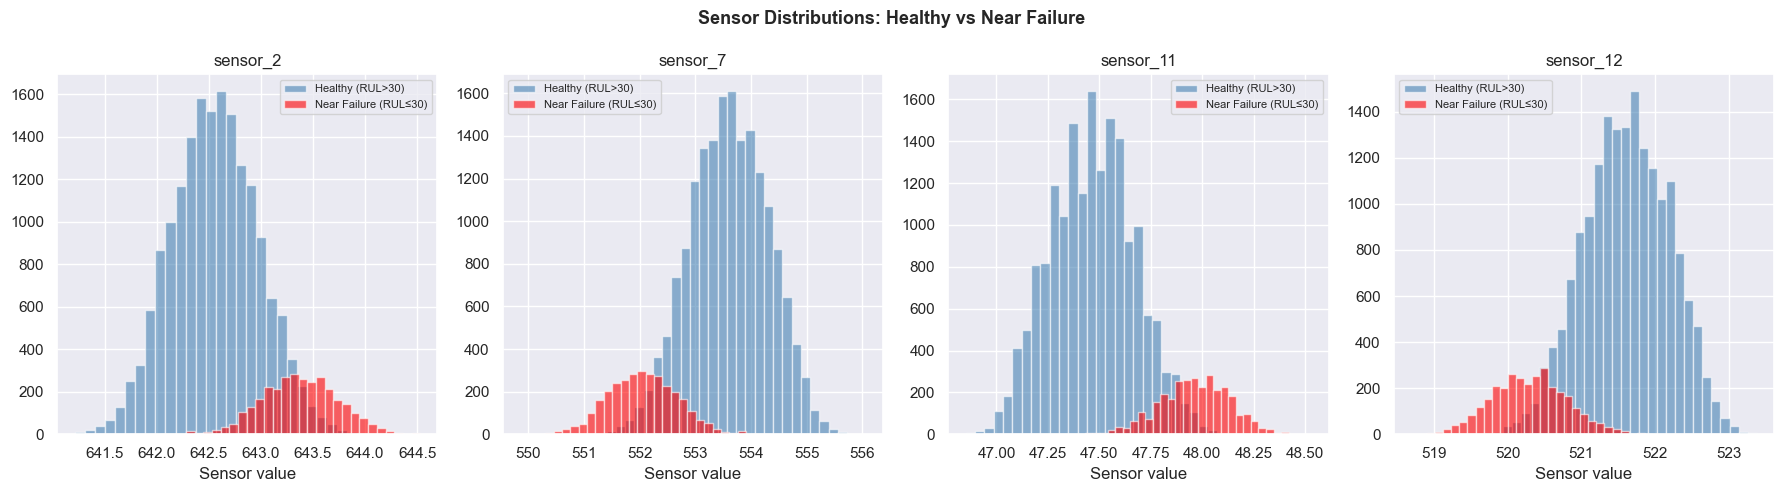

Plot 6 saved ✅


In [18]:
fd001 = train_df[train_df['subset'] == 'FD001'].copy()
fd001['health_status'] = pd.cut(fd001['RUL'], 
                                 bins=[-1, 30, 999], 
                                 labels=['Near Failure (RUL≤30)', 'Healthy (RUL>30)'])

top_sensors = ['sensor_2', 'sensor_7', 'sensor_11', 'sensor_12']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, sensor in enumerate(top_sensors):
    for status, color in [('Healthy (RUL>30)', 'steelblue'), 
                           ('Near Failure (RUL≤30)', 'red')]:
        data = fd001[fd001['health_status'] == status][sensor]
        axes[i].hist(data, bins=30, alpha=0.6, color=color, 
                     label=status, edgecolor='white')
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Sensor value')
    axes[i].legend(fontsize=8)

plt.suptitle('Sensor Distributions: Healthy vs Near Failure', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot6_healthy_vs_failure.png', dpi=150)
plt.show()
print("Plot 6 saved ✅")

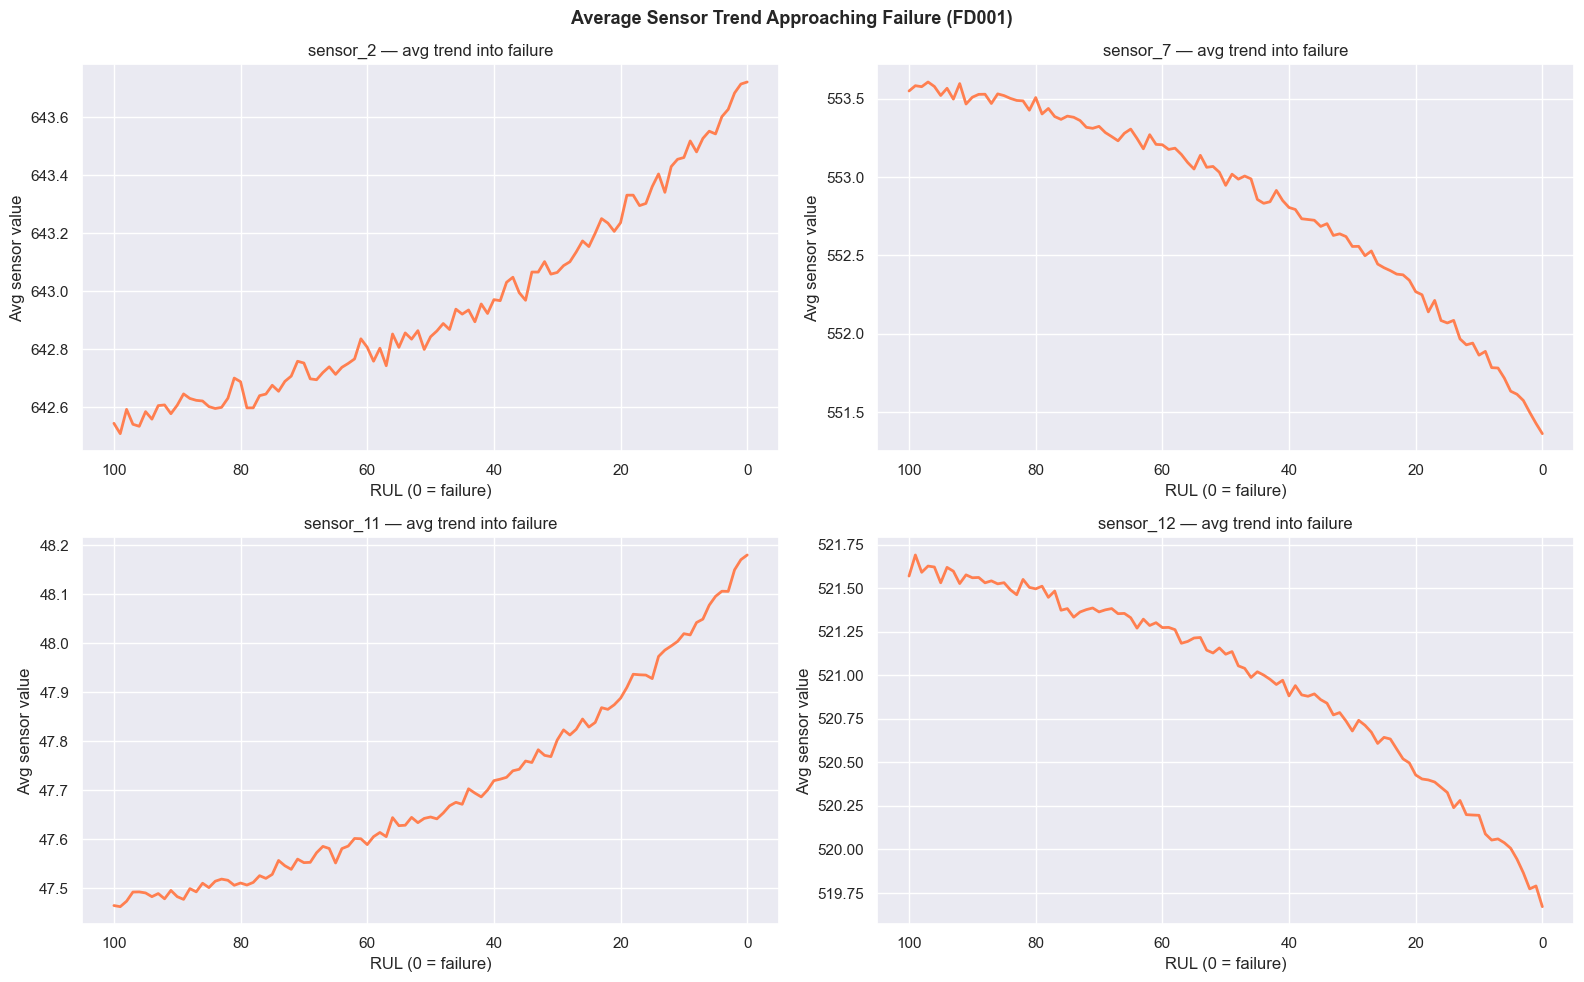

Plot 7 saved ✅


In [19]:
# Align all engines by RUL (0 = failure point)
# Look at the last 100 cycles before failure
fd001_last100 = fd001[fd001['RUL'] <= 100]

trend_sensors = ['sensor_2', 'sensor_7', 'sensor_11', 'sensor_12']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, sensor in enumerate(trend_sensors):
    avg_trend = fd001_last100.groupby('RUL')[sensor].mean()
    axes[i].plot(avg_trend.index[::-1], avg_trend.values[::-1], 
                 color='coral', linewidth=2)
    axes[i].set_title(f'{sensor} — avg trend into failure')
    axes[i].set_xlabel('RUL (0 = failure)')
    axes[i].set_ylabel('Avg sensor value')
    axes[i].invert_xaxis()

plt.suptitle('Average Sensor Trend Approaching Failure (FD001)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot7_failure_trend.png', dpi=150)
plt.show()
print("Plot 7 saved ✅")

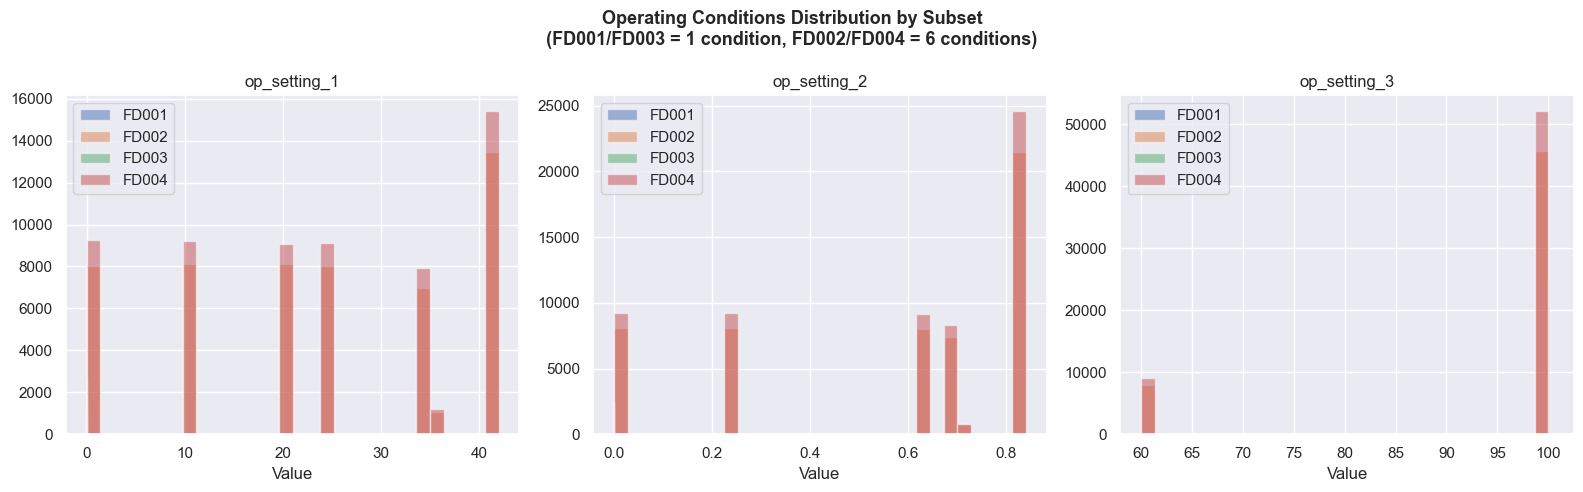

Plot 8 saved ✅


In [20]:
op_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(op_cols):
    for subset in ['FD001', 'FD002', 'FD003', 'FD004']:
        data = train_df[train_df['subset'] == subset][col]
        axes[i].hist(data, bins=30, alpha=0.5, label=subset)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].legend()

plt.suptitle('Operating Conditions Distribution by Subset\n(FD001/FD003 = 1 condition, FD002/FD004 = 6 conditions)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot8_operating_conditions.png', dpi=150)
plt.show()
print("Plot 8 saved ✅")